In [144]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [145]:
import numpy as np
import matplotlib.pyplot as plt     
from PostprocessingFunctions import write_vtk

In [146]:
%%bash
cd ..
g++ -std=c++17 -Wall Ramp.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o RampMMS 

        

SRC/Flux.cpp: In function ‘double p_func(double, double, double, double)’:
SRC/Flux.cpp:407:10: warning: unused variable ‘den’ [-Wunused-variable]
  407 |     auto den = (1+r > 0) - (1+r < 0);
      |          ^~~
SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:431:26: warning: unused variable ‘tol’ [-Wunused-variable]
  431 |             const double tol = 1e-14;
      |                          ^~~
SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:568:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  568 |         bool ghost_flag = false;
      |              ^~~~~~~~~~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:173:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  173 |     double gamma = 1.4;
      |            ^~~~~


In [147]:
%%bash
cd ..
./RampMMS

Shape = (13312, 4)
setting pointersSetting ambient Conditions...Setting inflow Conditions...Freestream Pressure: 80.8113   Freestream Density: 0.00544979 Freestream vel576.329Iteration: 0
Upwind Order: 0;  Norms:
  Density   : 8.2267e-06  U-velocity: 0.00474128  V-velocity: 9.193e-19  Pressure  : 1.79323
Iteration: 1
Upwind Order: 0;  Norms:
  Density   : 8.21608e-06  U-velocity: 0.00468207  V-velocity: 9.12786e-05  Pressure  : 1.7907
Iteration: 2
Upwind Order: 0;  Norms:
  Density   : 8.206e-06  U-velocity: 0.00462117  V-velocity: 0.00018604  Pressure  : 1.78829
Iteration: 3
Upwind Order: 0;  Norms:
  Density   : 8.19628e-06  U-velocity: 0.00455836  V-velocity: 0.0002845  Pressure  : 1.78596
Iteration: 4
Upwind Order: 0;  Norms:
  Density   : 8.18681e-06  U-velocity: 0.00449353  V-velocity: 0.000386742  Pressure  : 1.78367
Iteration: 5
Upwind Order: 0;  Norms:
  Density   : 8.17754e-06  U-velocity: 0.00442662  V-velocity: 0.000492777  Pressure  : 1.78143
Iteration: 6
Upwind Order: 0; 

In [148]:


data = np.loadtxt("../primitives.csv", delimiter=",")
NI = 64
NJ = 208
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 13312)


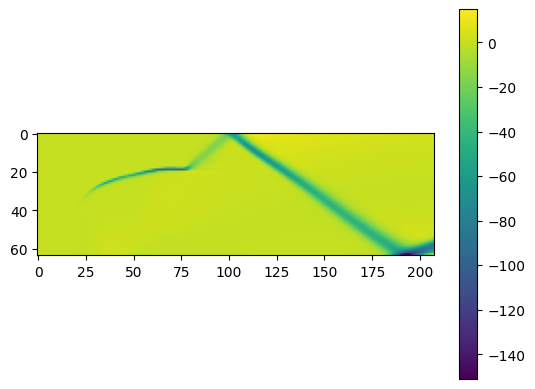

In [149]:
plt.imshow(p[::-1])
plt.colorbar()

In [150]:
from PostprocessingFunctions import load_grid
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.209x65.grd")



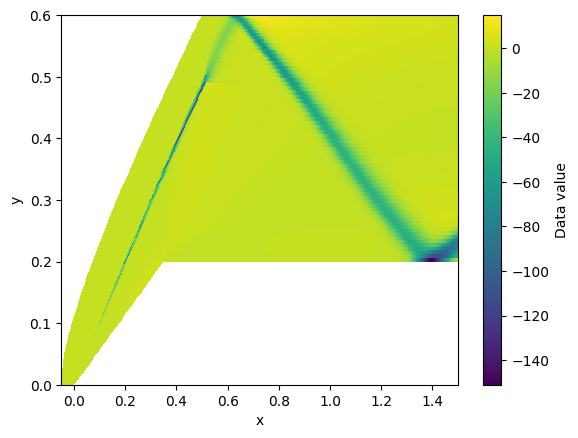

In [151]:
 

plt.pcolormesh(x, y, p, shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



In [152]:
write_vtk("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.105x33.grd",rho,u,v,p,output_name="../VTK/Fine_Ramp.vtk")

ValueError: Input point array shapes must match exactly